# Cell 1: Imports and Global Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Calculated optimal point of interest based on the pricing
ROME_LAT = 41.89790
ROME_LON = 12.47940

# Cell 2: Data Loading and Anomaly Cleaning
Loads the raw data, strips currency symbols, and filters edge-case prices and stays

default:  
min_price = 20  
max_price = 800 (note: due to the unpredictable distribution, later on we limit max price to 300)
max_min_nights = 30  

In [99]:
def load_listings(path="listings.csv"):
    return pd.read_csv(path, low_memory=False)

def clean_price(df, min_price=20, max_price=800, max_min_nights=30):
    df = df.copy()
    df["price"] = df["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["price"]).copy()
    df = df[(df["price"] >= min_price) & (df["price"] <= max_price)].copy()
    if "minimum_nights" in df.columns:
        df = df[df["minimum_nights"] <= max_min_nights].copy()
    return df

df_raw = load_listings()
df_clean = clean_price(df_raw)
print(f"Data cleaned. Remaining rows: {len(df_clean)}")

Data cleaned. Remaining rows: 28164


# Cell 3: Plot - Target Distribution

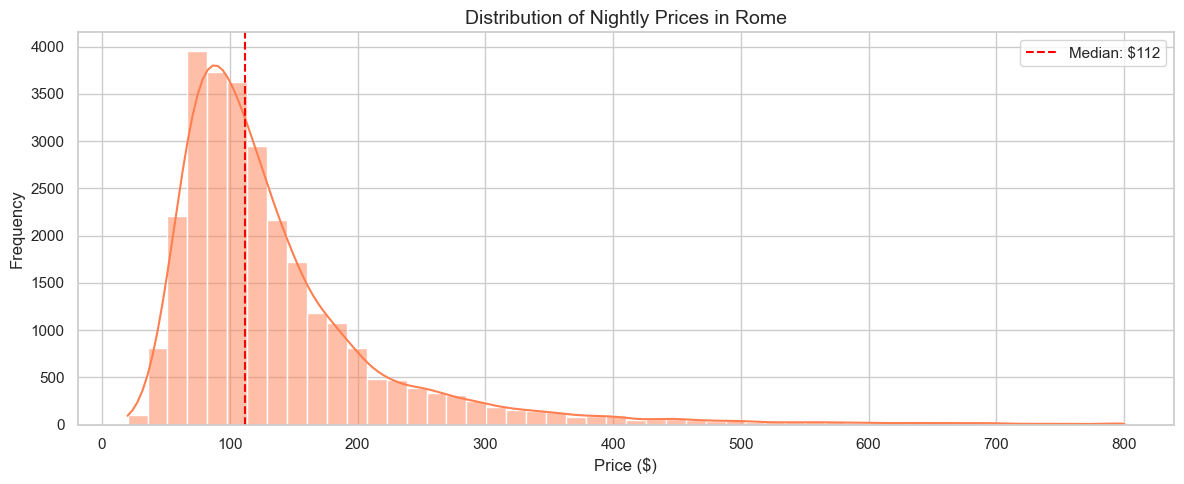

In [100]:
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['price'], bins=50, kde=True, color='coral')
plt.title('Distribution of Nightly Prices in Rome', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df_clean['price'].median(), color='red', linestyle='--', label=f"Median: ${df_clean['price'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

# Cell 4: Feature Engineering and Capacity Segmentation
Extracts text, geographic, and boolean features. Segmentation is purely based on capacity (Small, Mid, Large) to ensure statistical significance. Premium segment (>$300 or villa) is removed due to performance issues, those cannot be easly predicted and this infomration shall be passed to the post-prediction module for handling.

In [ ]:
def _haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin((p2 - p1) / 2) ** 2 + 
         np.cos(p1) * np.cos(p2) * np.sin((np.radians(lon2 - lon1)) / 2) ** 2)
    return r * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def add_features(df):
    df = df.copy()
    for col in ["accommodates", "bedrooms", "beds", "host_listings_count"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
            
    if "bathrooms" in df.columns or "bathrooms_text" in df.columns:
        df["bathrooms_cleaned"] = df.get("bathrooms").combine_first(
            df.get("bathrooms_text").astype(str).str.extract(r"(\d+\.?\d*)", expand=False).astype(float)
        ).fillna(1.0) 
        
    if "bedrooms" in df.columns:
        df["bedrooms_safe"] = df["bedrooms"].replace(0, 1)
        df["people_per_bedroom"] = df["accommodates"] / df["bedrooms_safe"]
        df["is_studio"] = ((df["bedrooms"] == 0) | df.get("property_type", "").str.contains("Studio", case=False, na=False)).astype(int)
    
    if "accommodates" in df.columns:
        df["baths_per_person"] = df["bathrooms_cleaned"] / df["accommodates"].replace(0, np.nan)
        
    if "latitude" in df.columns and "longitude" in df.columns:
        df["dist_center"] = _haversine(df["latitude"], df["longitude"], ROME_LAT, ROME_LON)
        
    if "amenities" in df.columns:
        amenities = df["amenities"].fillna("").astype(str).str.lower()
        df["has_ac"] = amenities.str.contains("air conditioning|ac").astype(int)
        df["has_elevator"] = amenities.str.contains("elevator").astype(int)
        df["has_parking"] = amenities.str.contains("free parking").astype(int)
        
    df["desc_len"] = df.get("description", pd.Series("")).fillna("").str.len()
    df["name_len"] = df.get("name", pd.Series("")).fillna("").str.len()
    
    bool_map = {"t": 1, "f": 0, "true": 1, "false": 0}
    if "instant_bookable" in df.columns:
        df["instant_bookable_flag"] = df["instant_bookable"].astype(str).str.lower().map(bool_map).fillna(0)
    if "host_is_superhost" in df.columns:
        df["superhost_flag"] = df["host_is_superhost"].astype(str).str.lower().map(bool_map).fillna(0)
    if "host_listings_count" in df.columns:
        df["is_pro_host"] = (df["host_listings_count"] > 1).astype(int)
        
    return df

def assign_segments(df):
    df = df.copy()
    amenities = df.get("amenities", pd.Series("")).fillna("").astype(str).str.lower()
    
    is_premium = (
        (df["price"] > 300) |
        (df.get("property_type", "").astype(str).str.contains("villa", case=False, na=False))
    )
    
    conditions = [is_premium, df["accommodates"] <= 2, df["accommodates"] <= 4]
    choices = ["premium", "small", "mid"]
    df["segment"] = np.select(conditions, choices, default="large")
    return df

print("Engineering features and assigning capacity segments...")
df_feat = add_features(df_clean)
df_all = assign_segments(df_feat)

# STRICT QUARANTINE
df_premium = df_all[df_all["segment"] == "premium"].copy()
df_core = df_all[df_all["segment"] != "premium"].copy()

print(f"Quarantined {len(df_premium)} Premium listings entirely.")
print(f"Remaining Core dataset (Small/Mid/Large) for Train/Test: {len(df_core)}")

Engineering features and assigning capacity segments...
Quarantined 1646 Premium listings entirely.
Remaining Core dataset (Small/Mid/Large) for Train/Test: 26518


# Cell 5: Train/Test Split and Geographic ML
We strictly split the data **before** target encoding or clustering. We use K-Means for spatial zones and 5-Fold Cross Validation within the training set to prevent data leakage.

In [ ]:
def apply_spatial_clusters(train_df, test_df, prem_df, n_clusters=30):
    train_df, test_df, prem_df = train_df.copy(), test_df.copy(), prem_df.copy()
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    
    train_df["spatial_zone"] = kmeans.fit_predict(train_df[["latitude", "longitude"]]).astype(str)
    test_df["spatial_zone"] = kmeans.predict(test_df[["latitude", "longitude"]]).astype(str)
    prem_df["spatial_zone"] = kmeans.predict(prem_df[["latitude", "longitude"]]).astype(str)
    return train_df, test_df, prem_df

def safe_target_encoding(train_df, test_df, prem_df, col="neighbourhood_cleansed", target="price", out_col=None):
    train_df, test_df, prem_df = train_df.copy(), test_df.copy(), prem_df.copy()
    if out_col is None: out_col = f"{col}_encoded"
        
    train_df[out_col] = 0.0
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(train_df):
        fold_train = train_df.iloc[train_idx]
        means = fold_train.groupby(col)[target].mean()
        train_df.iloc[val_idx, train_df.columns.get_loc(out_col)] = train_df.iloc[val_idx][col].map(means)
        
    global_mean = train_df[target].mean()
    train_df[out_col] = train_df[out_col].fillna(global_mean)
    
    # Map to test and premium
    mapping_means = train_df.groupby(col)[target].mean()
    test_df[out_col] = test_df[col].map(mapping_means).fillna(global_mean)
    prem_df[out_col] = prem_df[col].map(mapping_means).fillna(global_mean)
    return train_df, test_df, prem_df

train_df, test_df = train_test_split(df_core, test_size=0.2, random_state=42)
train_df, test_df, df_premium = apply_spatial_clusters(train_df, test_df, df_premium, n_clusters=30)
train_df, test_df, df_premium = safe_target_encoding(train_df, test_df, df_premium, col="neighbourhood_cleansed", out_col="neigh_encoded")
train_df, test_df, df_premium = safe_target_encoding(train_df, test_df, df_premium, col="spatial_zone", out_col="spatial_zone_encoded")
print("Data split and prepared for modeling.")

Data split and prepared for modeling.


# Cell 6: Plot - Geographic ML Clusters
note: An interactive map has been created as well as a separate script to visualize the clusters. This scatter plot proves why KMeans is better than linear "distance to center". Rome has multiple price hotspots, which clustering captures natively.

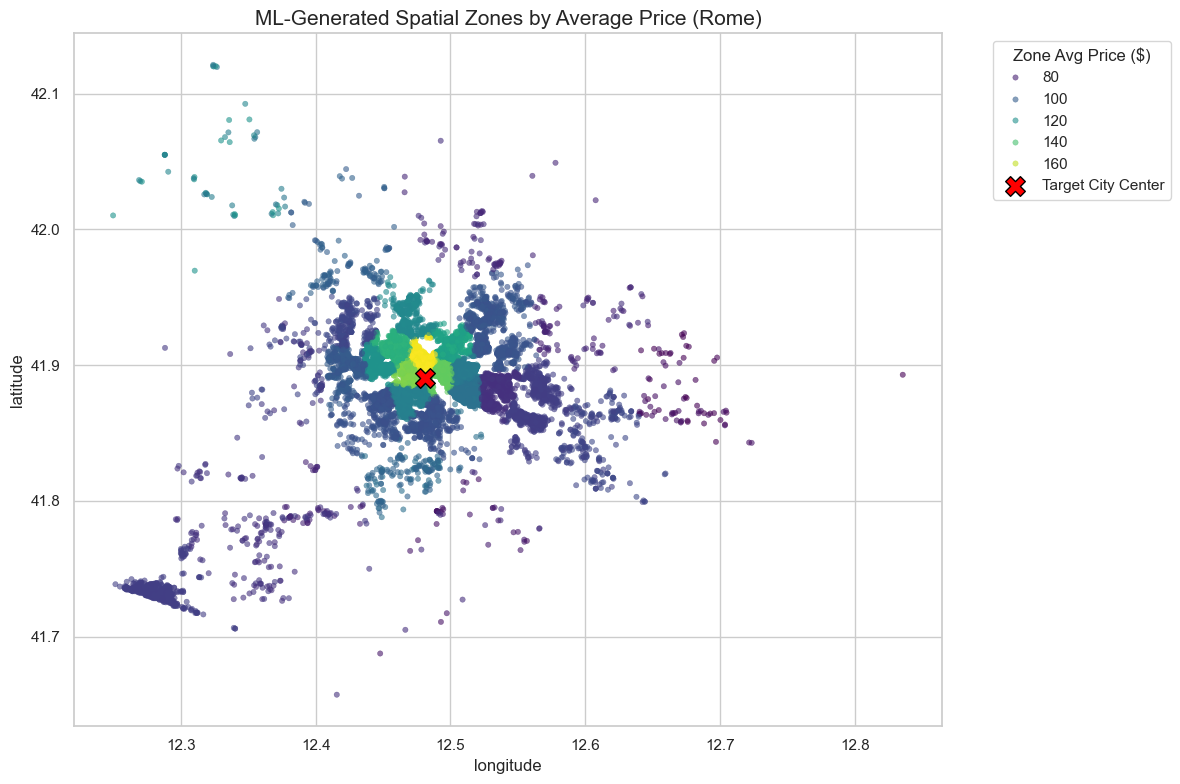

In [103]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='longitude', y='latitude', hue='spatial_zone_encoded', 
    palette='viridis', data=train_df, alpha=0.6, s=15, edgecolor=None
)
plt.scatter(ROME_LON, ROME_LAT, color='red', marker='X', s=200, label='Target City Center', edgecolor='black')
plt.title('ML-Generated Spatial Zones by Average Price (Rome)', fontsize=15)
plt.legend(title='Zone Avg Price ($)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cell 7: Outlier Removal and Model Training
Chosen model is a HistGradientBoostingRegressor wrapped with TransformedTargetRegressor which allow for better handling of missing data and non-linear relationships. Additionally, IsolationForest is used to remove outliers strictly from the training set. That possibly weird architecture proved to be one of the most effective and stable in training compared to more standard pipelines. There were no "pure" models that performed better.

In [ ]:
def filter_outliers_iforest(df, cols, contamination=0.03, random_state=42):
    use_cols = [c for c in cols if c in df.columns]
    if not use_cols: return df
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    mask = iso.fit_predict(df[use_cols]) == 1
    return df[mask].copy()
    
def train_segment_model(x_train, y_train):
    base = HistGradientBoostingRegressor(random_state=42)
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("hgb", base),
    ])
    return TransformedTargetRegressor(
        regressor=model, func=np.log1p, inverse_func=np.expm1
    ).fit(x_train, y_train)

base_features = [
    "accommodates", "dist_center", "bathrooms_cleaned", "baths_per_person", 
    "people_per_bedroom", "has_ac", "has_elevator", "has_parking", "is_pro_host", 
    "desc_len", "name_len", "is_studio", "instant_bookable_flag", "superhost_flag", 
    "minimum_nights", "beds", "neigh_encoded", "spatial_zone_encoded"
]

if "room_type" in train_df.columns:
    train_df = pd.get_dummies(train_df, columns=["room_type"], drop_first=True)
    test_df = pd.get_dummies(test_df, columns=["room_type"], drop_first=True)
    df_premium = pd.get_dummies(df_premium, columns=["room_type"], drop_first=True)
    
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)
    df_premium = df_premium.reindex(columns=train_df.columns, fill_value=0)

feature_cols = [f for f in train_df.columns if f in base_features or f.startswith("room_type_")]

print("Removing training outliers and building models...")
train_df_clean = filter_outliers_iforest(train_df, cols=["accommodates", "dist_center", "price"])

models = {}
for segment in ["small", "mid", "large"]:
    seg_train = train_df_clean[train_df_clean['segment'] == segment]
    if len(seg_train) > 100: 
        models[segment] = train_segment_model(seg_train[feature_cols], seg_train["price"])
        
default_model = train_segment_model(train_df_clean[feature_cols], train_df_clean["price"])
print("Training Complete on core data")

Removing training outliers and building models...
Training Complete on core data


# Cell 8: Plot - Permutation Feature Importance
Simple permutation importance to identify which features actually drive the model's predictions.

Feature importance calculation...


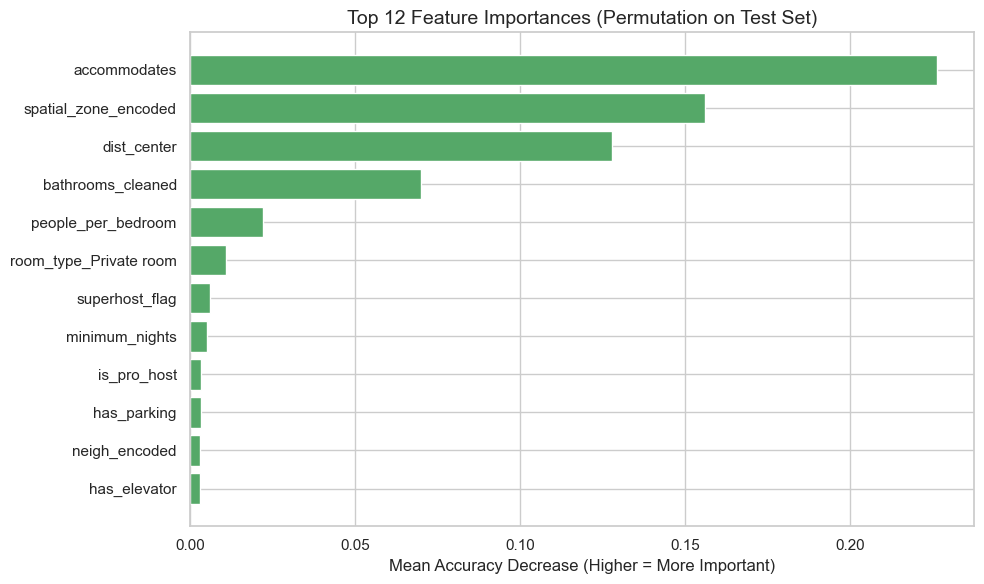

In [105]:
print("Feature importance calculation...")
result = permutation_importance(
    default_model, test_df[feature_cols], test_df['price'], 
    n_repeats=5, random_state=42, n_jobs=-1
)

sorted_idx = result.importances_mean.argsort()[-12:] 
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], color="#55A868")
plt.yticks(range(len(sorted_idx)), [feature_cols[i] for i in sorted_idx])
plt.title("Top 12 Feature Importances (Permutation on Test Set)", fontsize=14)
plt.xlabel("Mean Accuracy Decrease (Higher = More Important)", fontsize=12)
plt.tight_layout()
plt.show()

# Cell 9: Generating Predictions and Baselines
Generates predictions for our model AND two baseline models to evaluate true uplift.
- Core model: Our trained model as described in Cell 7
- Baseline 1: Global median price
- Baseline 2: Median price by neighborhood cluster

In [106]:
# 1. CORE TEST SET PREDICTIONS
test_df["pred_ml_model"] = np.nan
for segment, group in test_df.groupby("segment"):
    model = models.get(segment, default_model)
    test_df.loc[group.index, "pred_ml_model"] = model.predict(group[feature_cols])

# 2. CORE BASELINES
global_median = train_df_clean["price"].median()
test_df["pred_global_baseline"] = global_median
district_medians = train_df_clean.groupby("neighbourhood_cleansed")["price"].median()
test_df["pred_district_baseline"] = test_df["neighbourhood_cleansed"].map(district_medians).fillna(global_median)

# 3. PREMIUM PREDICTIONS (STRICT QUARANTINE) - for future plots
df_premium["pred_ml_model"] = default_model.predict(df_premium[feature_cols])

# Cell 10: Plot - Residual Error Analysis

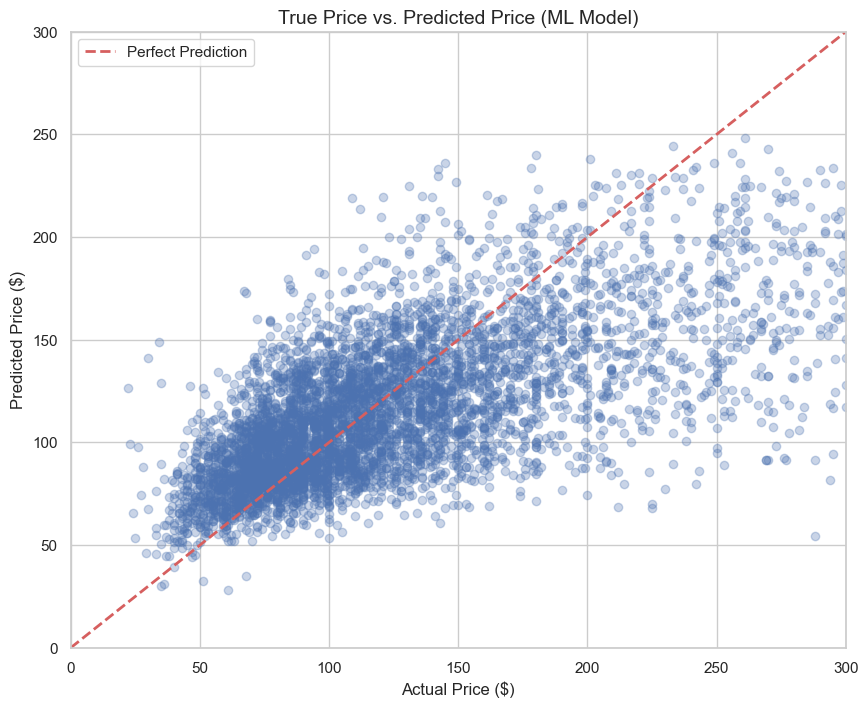

In [107]:
plt.figure(figsize=(10, 8))
plt.scatter(test_df['price'], test_df['pred_ml_model'], alpha=0.3, color='#4C72B0')
plt.plot([0, 300], [0, 300], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.title('True Price vs. Predicted Price (ML Model)', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.show()

# Cell 11: Business Report - Baseline Comparisons

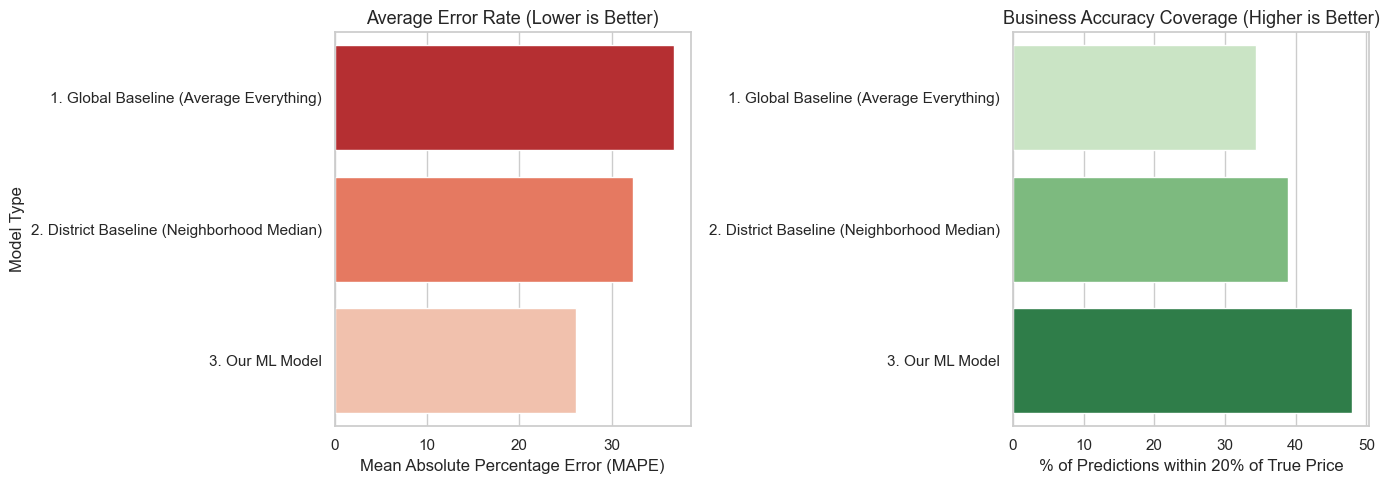

,Model Type,MAPE (%),Accuracy +/- 20%
0,1. Global Baseline (Average Everything),36.73,34.39
1,2. District Baseline (Neighborhood Median),32.35,38.93
2,3. Our ML Model,26.11,47.94


In [108]:
def get_metrics(y_true, y_pred, name):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    cov_20 = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.20) * 100
    return {"Model Type": name, "MAPE (%)": mape, "Accuracy +/- 20%": cov_20}

baseline_metrics = [
    get_metrics(test_df["price"], test_df["pred_global_baseline"], "1. Global Baseline (Average Everything)"),
    get_metrics(test_df["price"], test_df["pred_district_baseline"], "2. District Baseline (Neighborhood Median)"),
    get_metrics(test_df["price"], test_df["pred_ml_model"], "3. Our ML Model")
]
df_results = pd.DataFrame(baseline_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results, x="MAPE (%)", y="Model Type", ax=axes[0], palette="Reds_r")
axes[0].set_title("Average Error Rate (Lower is Better)", fontsize=13)
axes[0].set_xlabel("Mean Absolute Percentage Error (MAPE)")

sns.barplot(data=df_results, x="Accuracy +/- 20%", y="Model Type", ax=axes[1], palette="Greens")
axes[1].set_title("Business Accuracy Coverage (Higher is Better)", fontsize=13)
axes[1].set_xlabel("% of Predictions within 20% of True Price")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
display(df_results.round(2))

### **Conclusions**
As visible in the results, out model significantly outperforms both baselines by consequently 10.62 and 6.24 percentage points in terms of MAPE. Especially in comparison to the neighborhood median, which is a common industry practice, our model's ability to capture complex interactions and non-linear relationships allows it to provide more accurate predictions, demonstrating its value in a real-world setting.

NNonetheless, it is important to mention that while our model shows a significant improvement over the baselines, it is still far from being a perfect predictor. The MAPE of ~26.11% is a result of long and tideous process of data cleaning, feature engineering and training dozens of different models and pipelines. This highlights that holiday rental pricing is a complex problem influenced by many factors many of which are outside of the available dataset. Therefore, it advised to use the model's predictions as a guide rather than an absolute value, and to continuously monitor and update the model as new data becomes available.

One of possible approaches that should provide helpful information for apartment owners is to output a range of prices (f.e. 0.85 to 1.15 of the predicted price) instead of a single point estimate, leaving the final decision to the user who knows their property best and can take into account factors that are not captured in the data. 

# Cell 12: Investor Report - Premium Tier Quantization
Demonstrates that standard tabular data fails to price the "Premium" (>$300) tier, requiring a separate business flow. Attempting to predict Premium/Luxury pricing using standard tabular data yields a massive error rate. These listings require distinct business logic or computer vision for image appraisal.

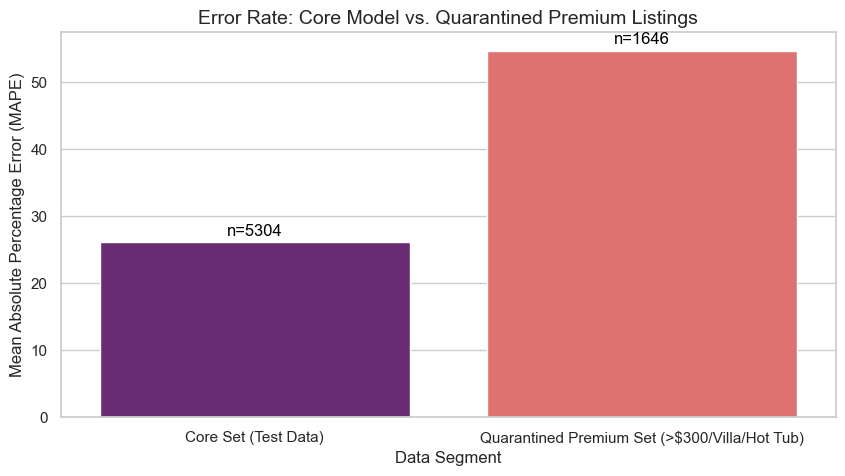

In [109]:
premium_mape = np.mean(np.abs((df_premium["price"] - df_premium["pred_ml_model"]) / df_premium["price"])) * 100

failure_df = pd.DataFrame({
    "Data Segment": ["Core Set (Test Data)", "Quarantined Premium Set (>$300/Villa/Hot Tub)"],
    "Listing Count": [len(test_df), len(df_premium)],
    "MAPE (%)": [df_results.loc[2, "MAPE (%)"], premium_mape]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=failure_df, x="Data Segment", y="MAPE (%)", palette="magma")
plt.title("Error Rate: Core Model vs. Quarantined Premium Listings", fontsize=14)
plt.ylabel("Mean Absolute Percentage Error (MAPE)")
for index, row in failure_df.iterrows():
    plt.text(index, row["MAPE (%)"] + 1, f"n={row['Listing Count']}", color='black', ha="center")
plt.show()

# Cell 13: Exporting Model Weights

In [110]:
print("Saving model weights and feature lists...")
joblib.dump(models, 'segmented_pricing_models.joblib')
joblib.dump(default_model, 'default_pricing_model.joblib')
joblib.dump(feature_cols, 'model_feature_columns.joblib')
print("Models successfully saved to disk as .joblib files.")

Saving model weights and feature lists...
Models successfully saved to disk as .joblib files.
